In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import logging
from utils.clause_visualization import visualize_aggregated_heatmap, visualize_per_channel_heatmaps, visualize_per_channel_level_heatmaps, visualize_average_heatmap

2026-03-25 21:14:45,178 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data
2026-03-25 21:14:45,185 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib
2026-03-25 21:14:45,198 - matplotlib - DEBUG - interactive is False
2026-03-25 21:14:45,199 - matplotlib - DEBUG - platform is linux
2026-03-25 21:14:45,479 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib
2026-03-25 21:14:45,480 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

In [3]:
num_clauses = 8000
T = 6000
s = 5.0
max_included_literals = 32
device = "CPU"
epochs = 5
patch_size = 6
weighted_clauses=True 
resolution = 8

In [4]:
import numpy as np
from torchvision import datasets

# Download MNIST
train_ds = datasets.MNIST(root="./data", train=True, download=True)
test_ds  = datasets.MNIST(root="./data", train=False, download=True)

# Convert to NumPy
X_all = train_ds.data.numpy()        
Y_all = train_ds.targets.numpy()

X_test_all = test_ds.data.numpy()   
Y_test_all = test_ds.targets.numpy()

rng = np.random.default_rng(42)

train_idx = rng.choice(len(X_all), size=int(0.4 * len(X_all)), replace=False)
test_idx  = rng.choice(len(X_test_all), size=int(0.4 * len(X_test_all)), replace=False)

X_subset = X_all[train_idx]
Y_subset = Y_all[train_idx]

X_test_org = X_test_all[test_idx]
Y_test     = Y_test_all[test_idx]

split = int(0.8 * len(X_subset))  

X_train_org = X_subset[:split]
Y_train     = Y_subset[:split]

X_val_org   = X_subset[split:]
Y_val       = Y_subset[split:]

# Ensure standard dtypes
X_train_org = X_train_org.astype(np.uint8)
X_val_org   = X_val_org.astype(np.uint8)
X_test_org  = X_test_org.astype(np.uint8)

# Final aliases (same as your original code)
X_train = X_train_org
X_val   = X_val_org
X_test  = X_test_org

print("Raw shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Labels:", Y_train.shape, Y_val.shape, Y_test.shape)

labels = {
    0: "Zero",
    1: "One",
    2: "Two",
    3: "Three",
    4: "Four",
    5: "Five",
    6: "Six",
    7: "Seven",
    8: "Eight",
    9: "Nine"
}

print(labels)

X_train = np.empty(
    (
        X_train_org.shape[0],   # N
        X_train_org.shape[1],   # H
        X_train_org.shape[2],   # W
        resolution,             # number of threshold levels
    ),
    dtype=np.uint8,
)

for z in range(resolution):
    threshold = (z + 1) * 255 / (resolution + 1)
    X_train[:, :, :, z] = X_train_org[:, :, :] >= threshold


# ---- TEST ----
X_test = np.empty(
    (
        X_test_org.shape[0],
        X_test_org.shape[1],
        X_test_org.shape[2],
        resolution,
    ),
    dtype=np.uint8,
)

for z in range(resolution):
    threshold = (z + 1) * 255 / (resolution + 1)
    X_test[:, :, :, z] = X_test_org[:, :, :] >= threshold


# ---- VAL ----
X_val = np.empty(
    (
        X_val_org.shape[0],
        X_val_org.shape[1],
        X_val_org.shape[2],
        resolution,
    ),
    dtype=np.uint8,
)

for z in range(resolution):
    threshold = (z + 1) * 255 / (resolution + 1)
    X_val[:, :, :, z] = X_val_org[:, :, :] >= threshold


# ---- RESHAPE (now just (N, H, W, resolution)) ----
X_train = X_train.reshape(
    (
        X_train_org.shape[0],
        X_train_org.shape[1],
        X_train_org.shape[2],
        resolution,
    )
)

X_test = X_test.reshape(
    (
        X_test_org.shape[0],
        X_test_org.shape[1],
        X_test_org.shape[2],
        resolution,
    )
)

X_val = X_val.reshape(
    (
        X_val_org.shape[0],
        X_val_org.shape[1],
        X_val_org.shape[2],
        resolution,
    )
)

# ---- LABEL FLATTENING ----
Y_train = Y_train.reshape(Y_train.shape[0])
Y_test  = Y_test.reshape(Y_test.shape[0])
Y_val   = Y_val.reshape(Y_val.shape[0])

X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

Raw shapes: (19200, 28, 28) (4800, 28, 28) (4000, 28, 28)
Labels: (19200,) (4800,) (4000,)
{0: 'Zero', 1: 'One', 2: 'Two', 3: 'Three', 4: 'Four', 5: 'Five', 6: 'Six', 7: 'Seven', 8: 'Eight', 9: 'Nine'}


In [5]:
tm = TMClassifier(
        number_of_clauses=num_clauses,
        T=T,
        s=s,
        max_included_literals=max_included_literals,
        platform="CPU",
        weighted_clauses=weighted_clauses,
        patch_dim=(patch_size, patch_size),
    )


In [6]:
# for epoch in range(3):
#         start = time()

#         tm.fit(X_train, Y_train, epochs=1, incremental=True)

#         stop = time()

#         Y_pred, class_sums = tm.predict(X_test, return_class_sums=True)

#         acc = 100.0 * (Y_pred == Y_test).mean()
#         print(f"#{epoch+1} Accuracy: {acc:.2f}% ({stop-start:.2f}s)")

In [6]:
import pickle 

# with open("mnist_40_resolution.pkl", "wb") as f:
    # pickle.dump(tm, f)

In [7]:
with open("mnist_40_resolution.pkl", "rb") as f:
    tm = pickle.load(f)

In [9]:
n_literals = tm.clause_banks[0].number_of_literals
print(f"Number of literals: {n_literals}")

Number of literals: 664


Showing sample index: 3958
Visualizing sample 3958  |  predicted class: 3


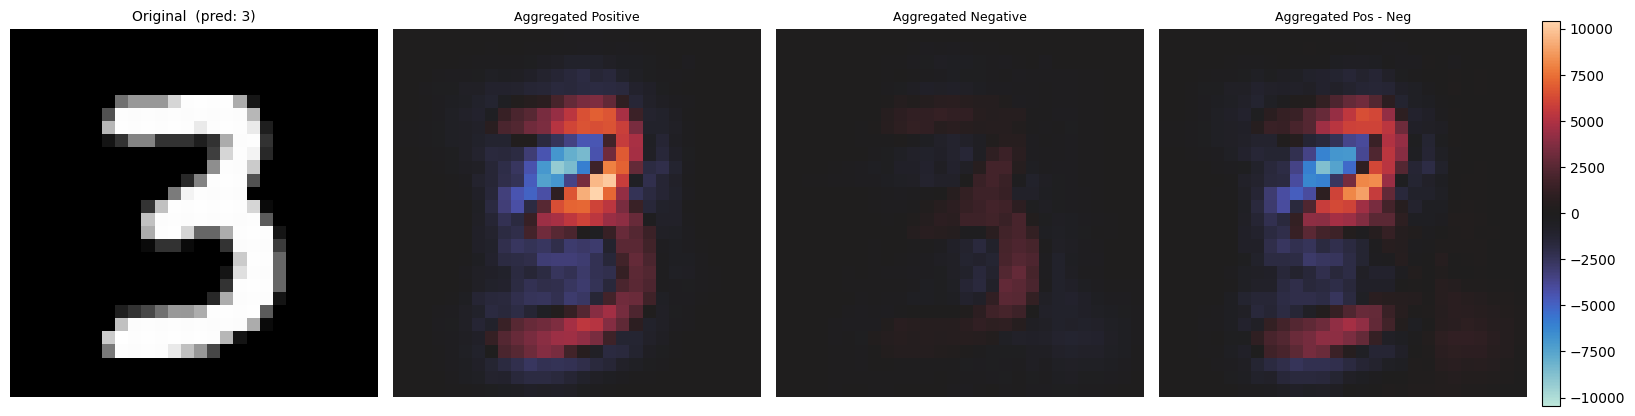

Visualizing sample 3958  |  predicted class: 3


/home/coder/masters_thesis/utils/clause_visualization.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


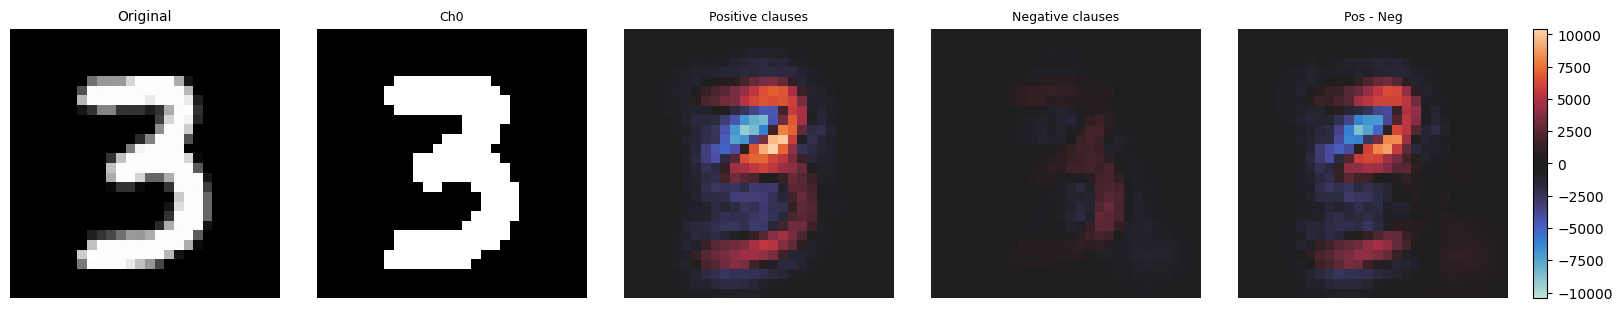

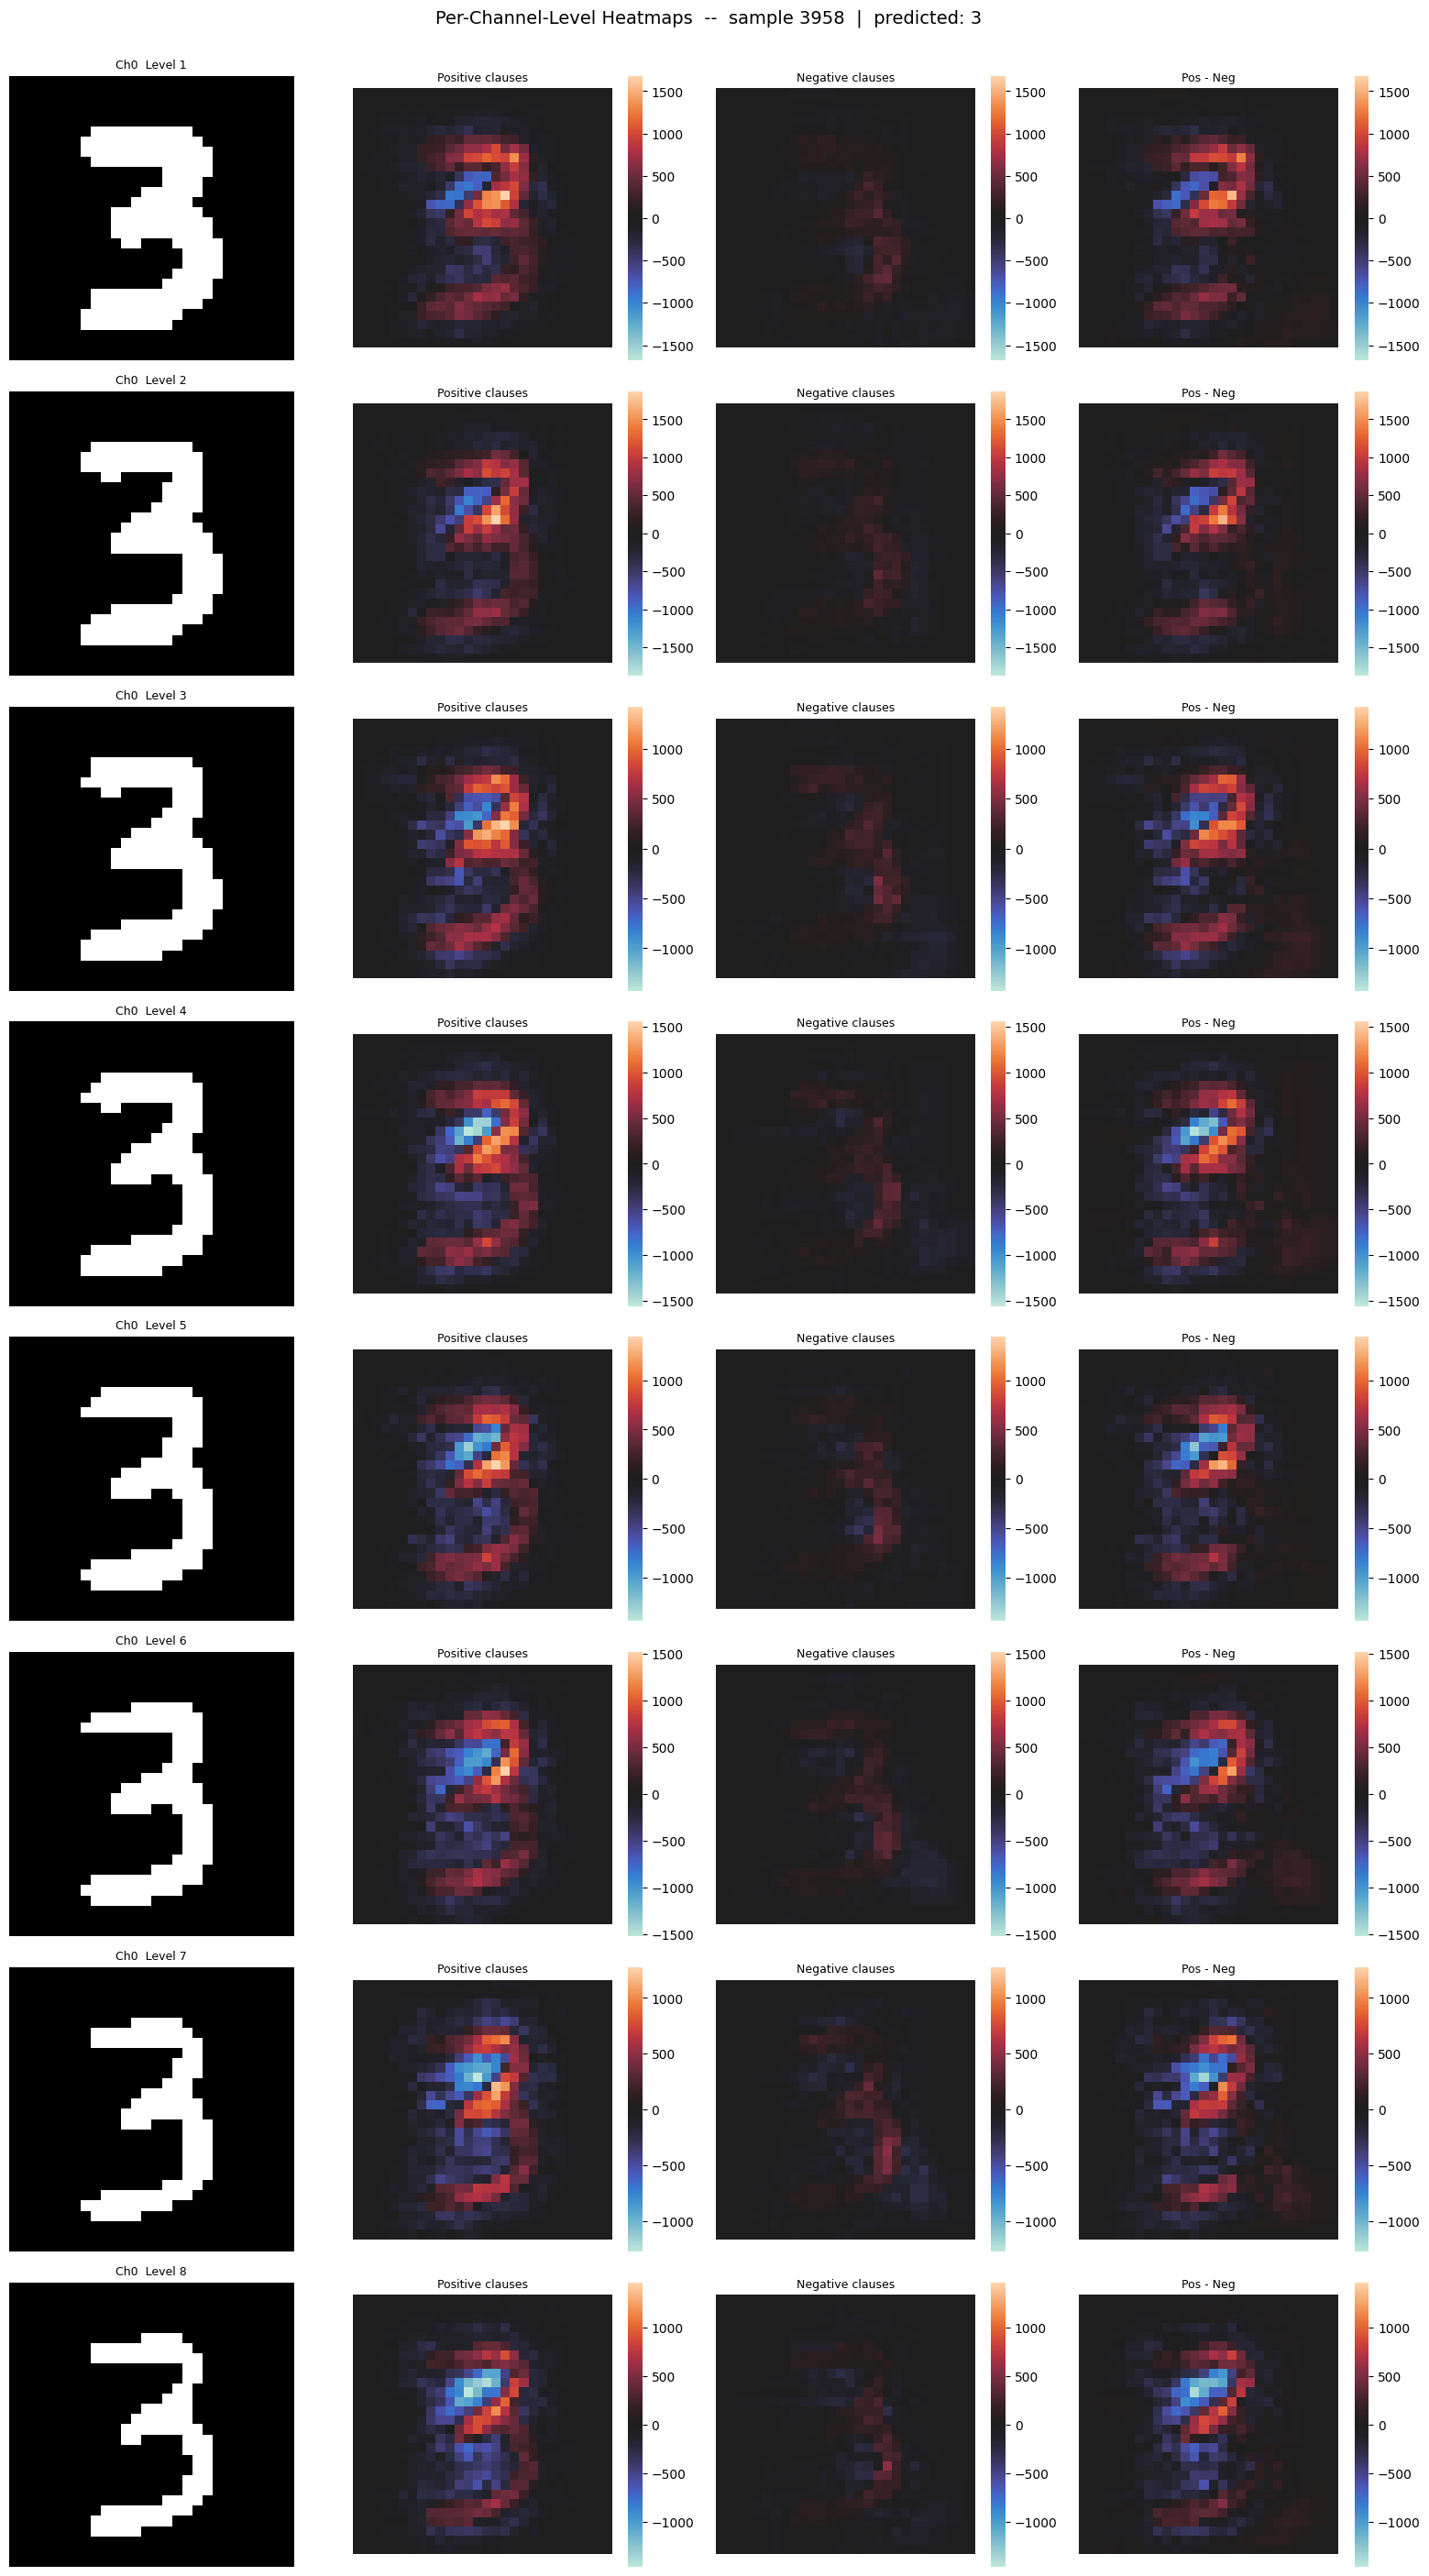

In [8]:
image_index = np.random.randint(0, len(X_test))
print(f"Showing sample index: {image_index}")

visualize_aggregated_heatmap(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=resolution,
    n_channels=1,
    image_shape=(28, 28))

visualize_per_channel_heatmaps(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=resolution,
    n_channels=1,
    image_shape=(28, 28))

visualize_per_channel_level_heatmaps(X_test, X_test_org, tm,
    image_index=image_index,
    resolution=resolution,
    n_channels=1,
    image_shape=(28, 28))

Averaging over 200 correctly predicted samples of class 0


  processed 100/200


  processed 200/200


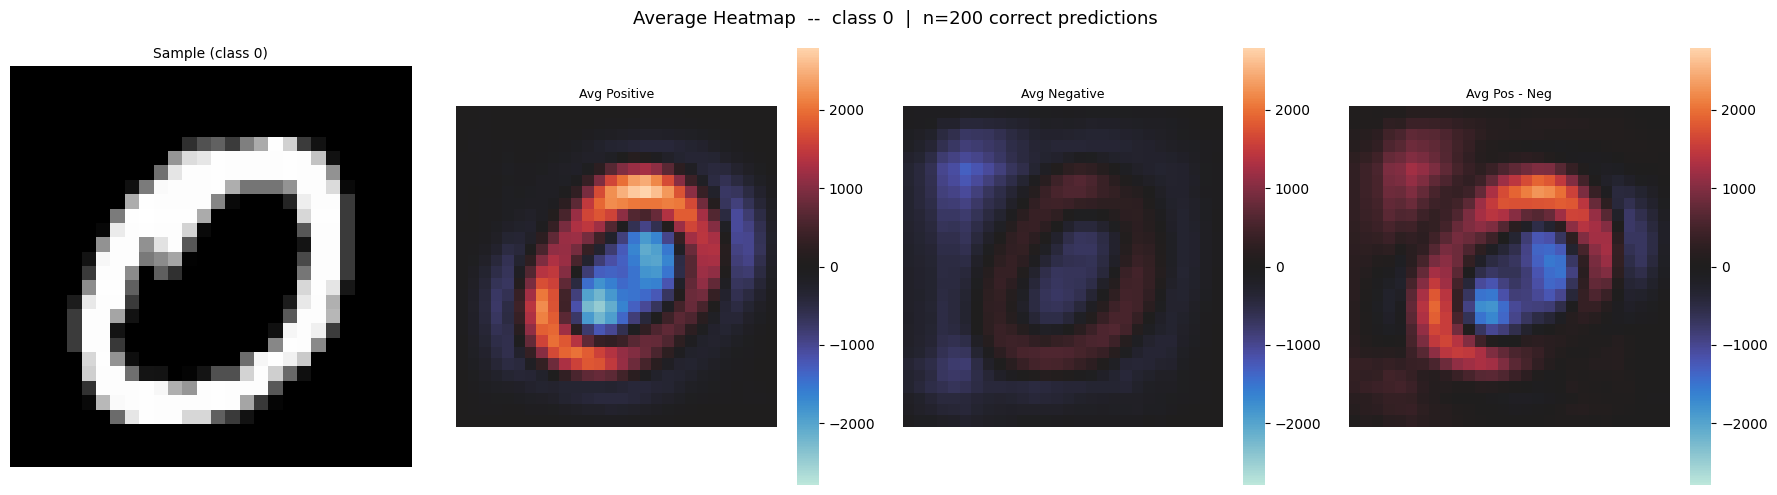

Averaging over 200 correctly predicted samples of class 1


  processed 100/200


  processed 200/200


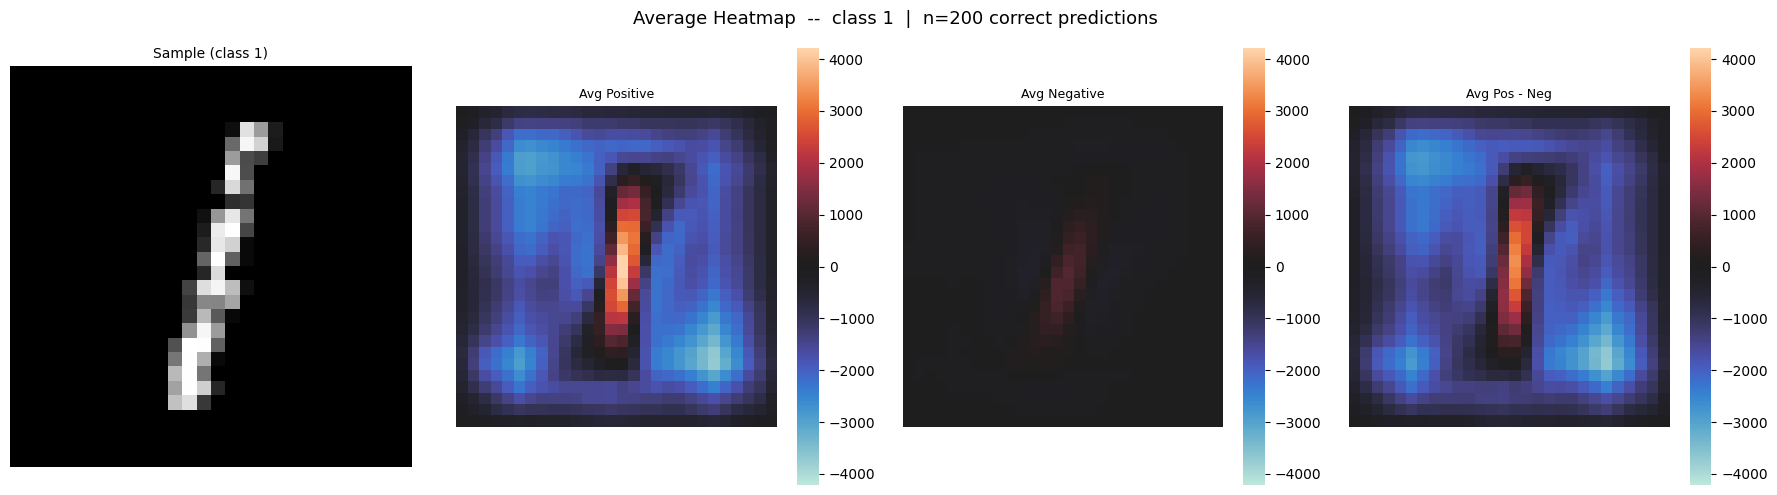

Averaging over 200 correctly predicted samples of class 2


  processed 100/200


  processed 200/200


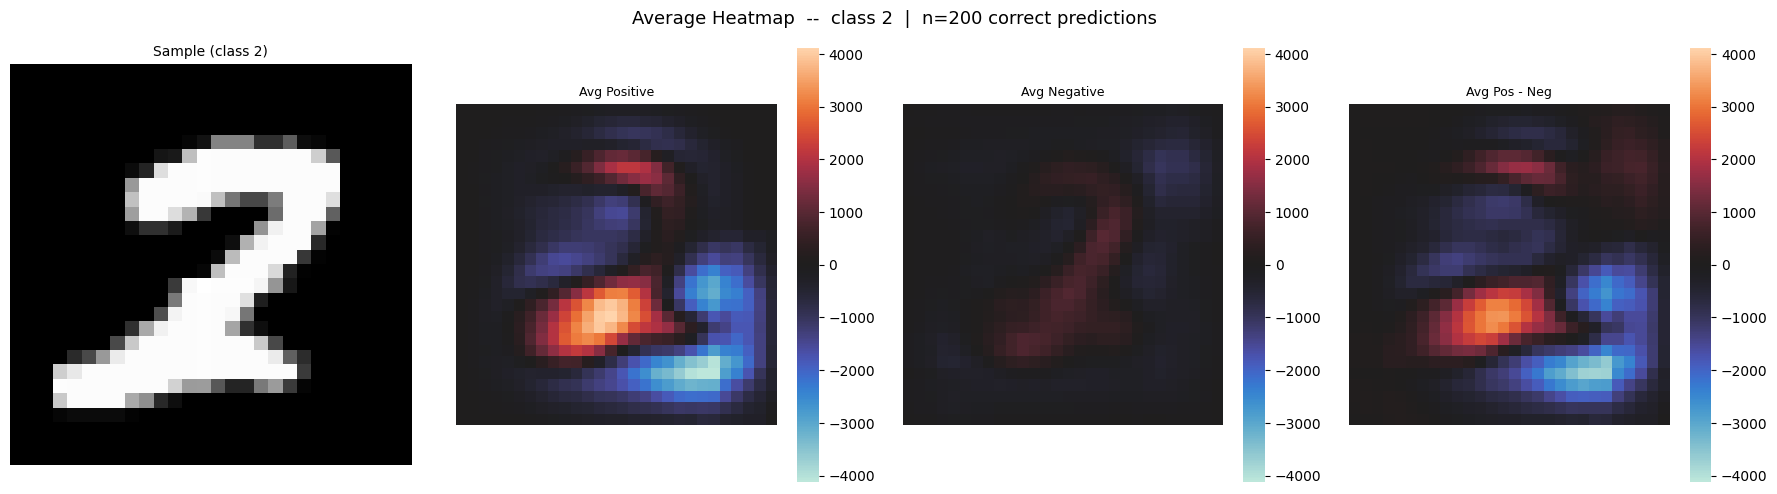

Averaging over 200 correctly predicted samples of class 3


  processed 100/200


  processed 200/200


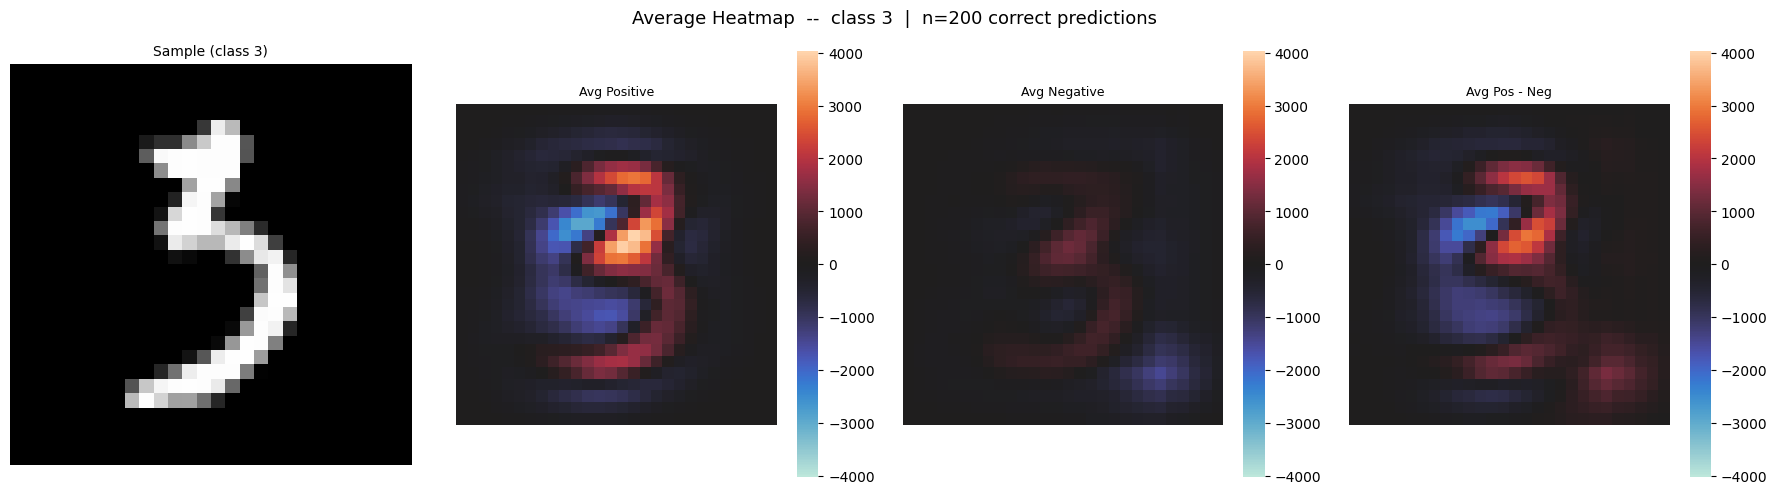

Averaging over 200 correctly predicted samples of class 4


  processed 100/200


  processed 200/200


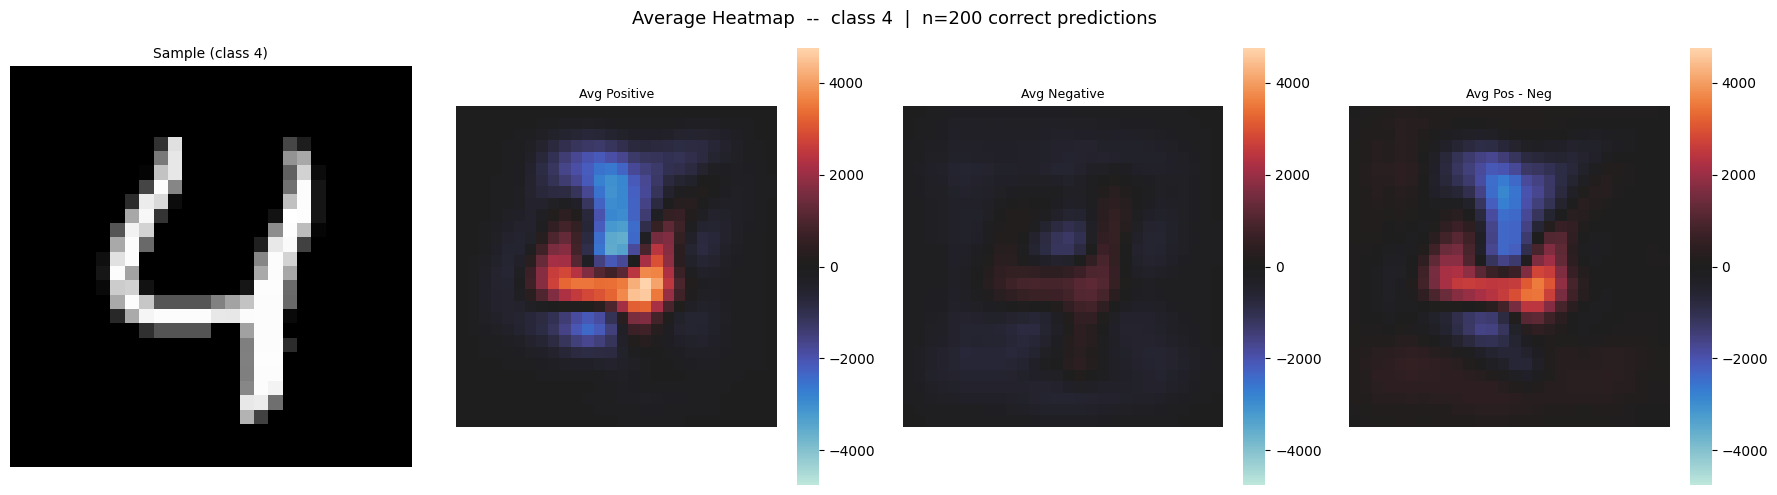

Averaging over 200 correctly predicted samples of class 5


  processed 100/200


  processed 200/200


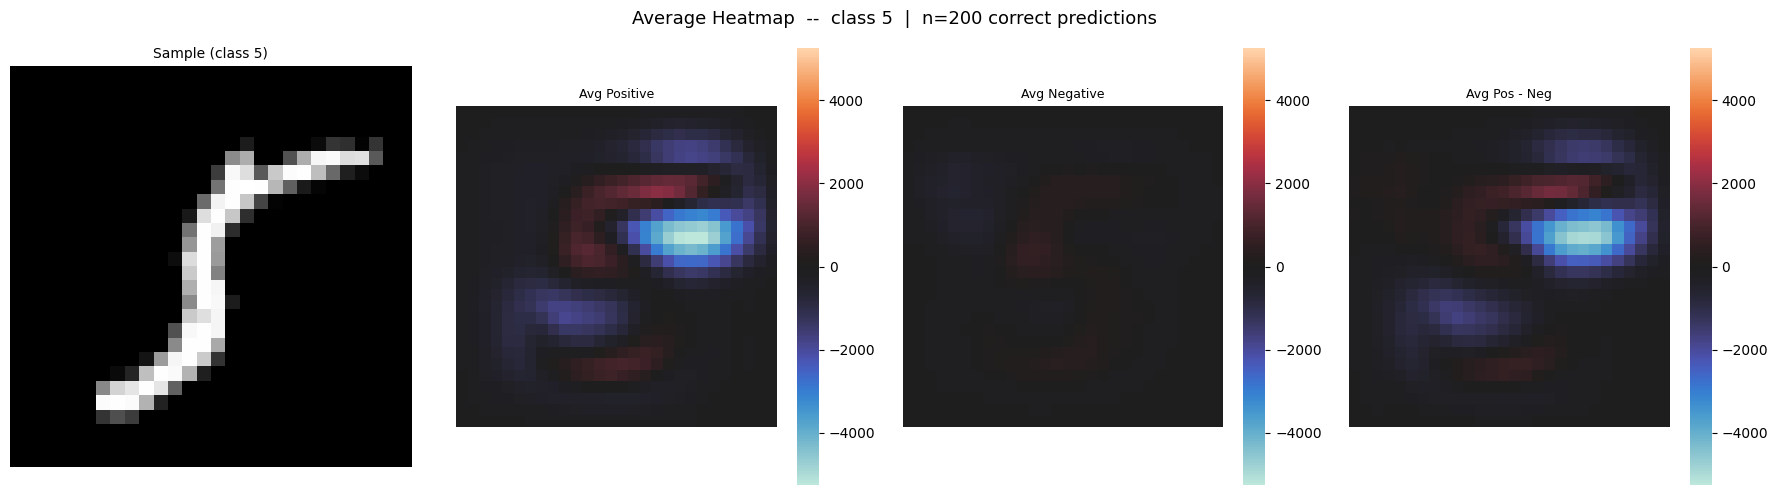

Averaging over 200 correctly predicted samples of class 6


  processed 100/200


  processed 200/200


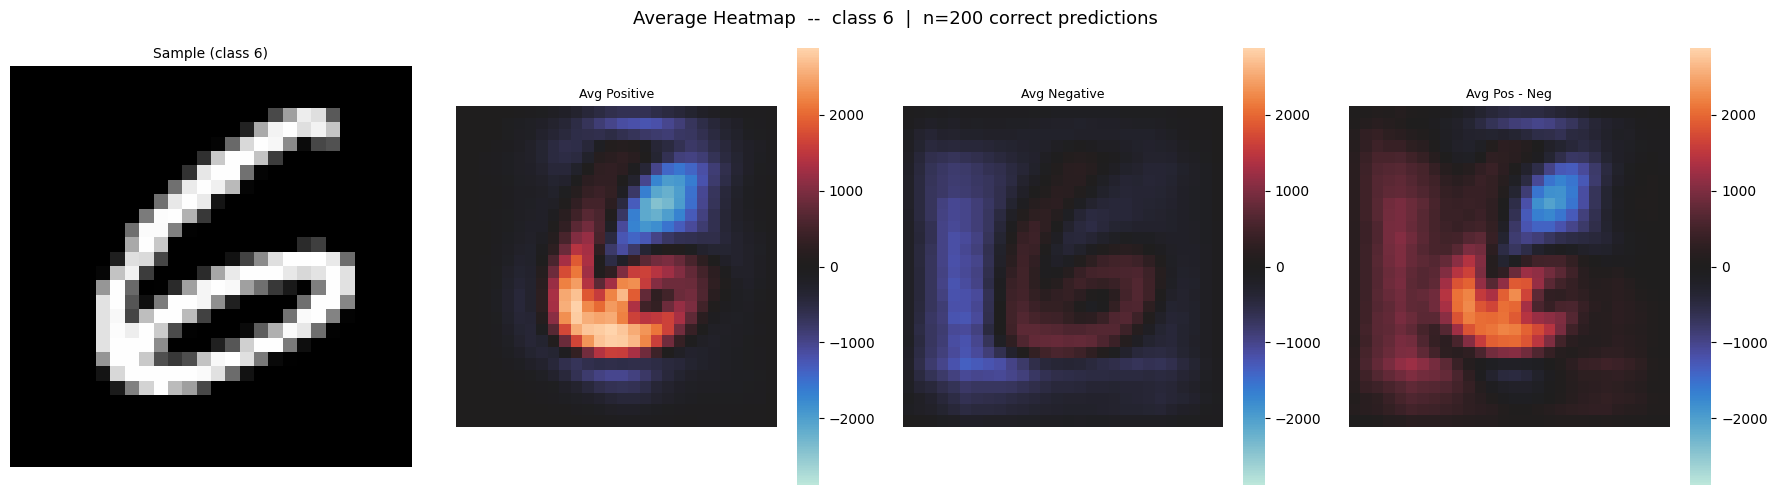

Averaging over 200 correctly predicted samples of class 7


  processed 100/200


  processed 200/200


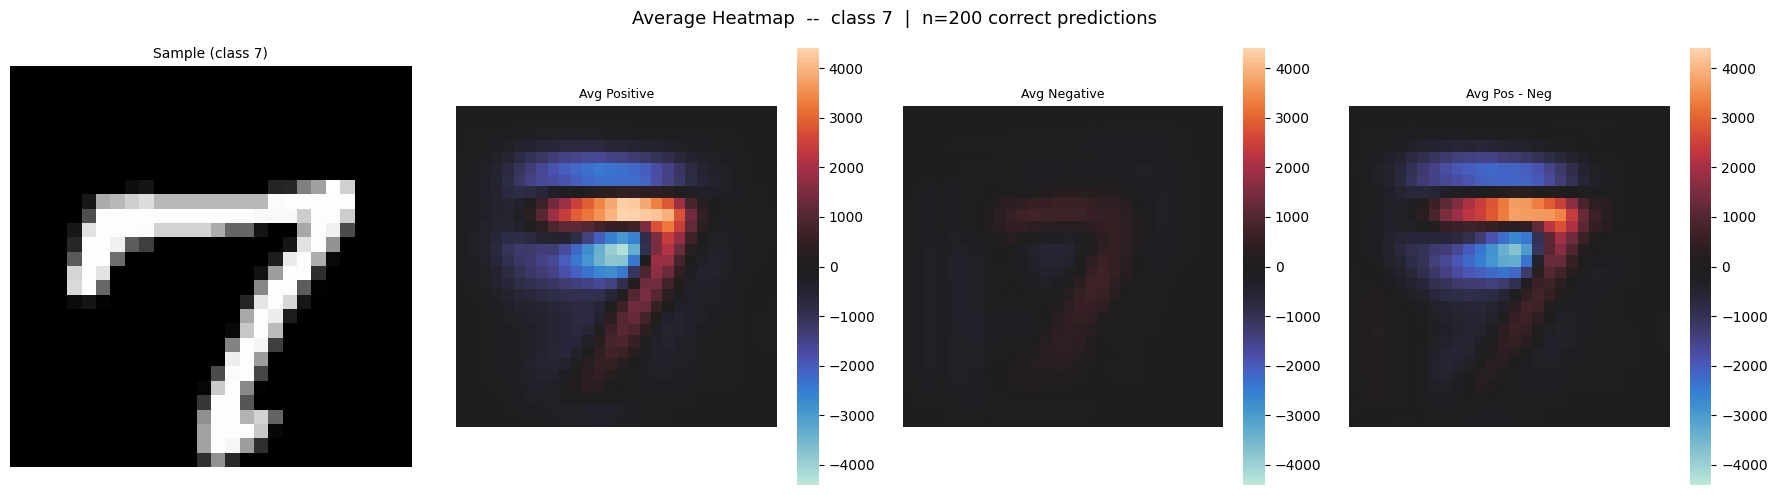

Averaging over 200 correctly predicted samples of class 8


  processed 100/200


  processed 200/200


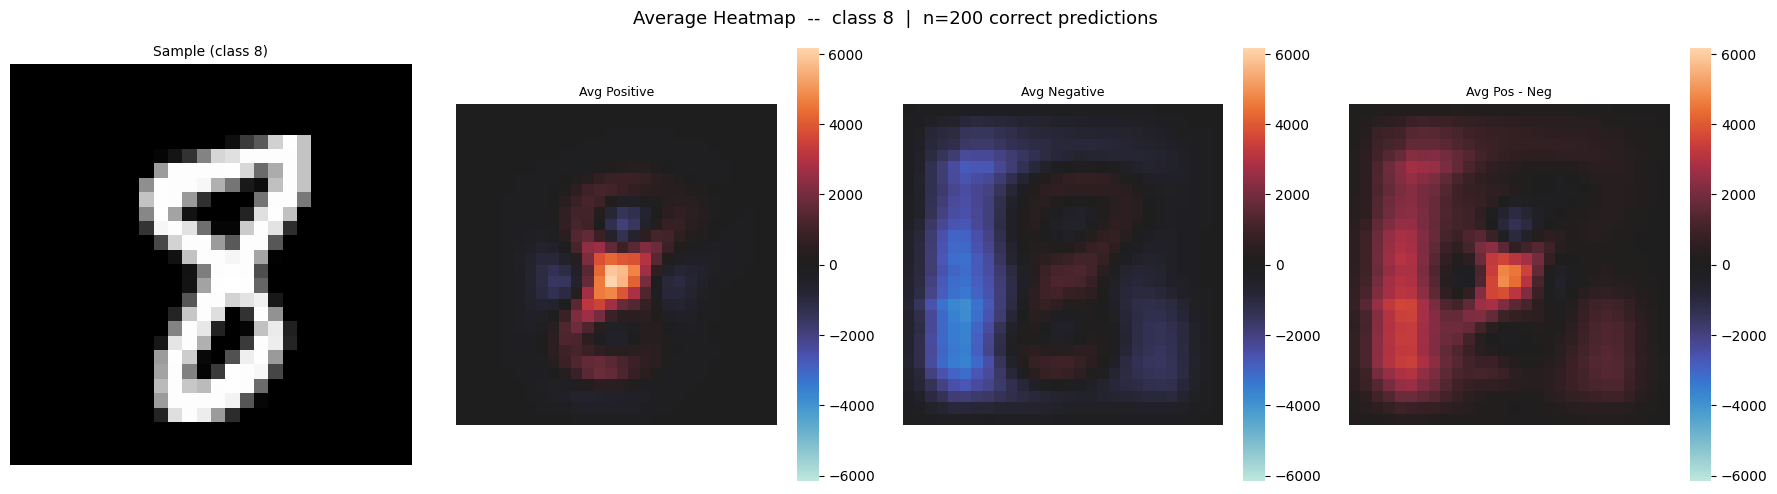

Averaging over 200 correctly predicted samples of class 9


  processed 100/200


  processed 200/200


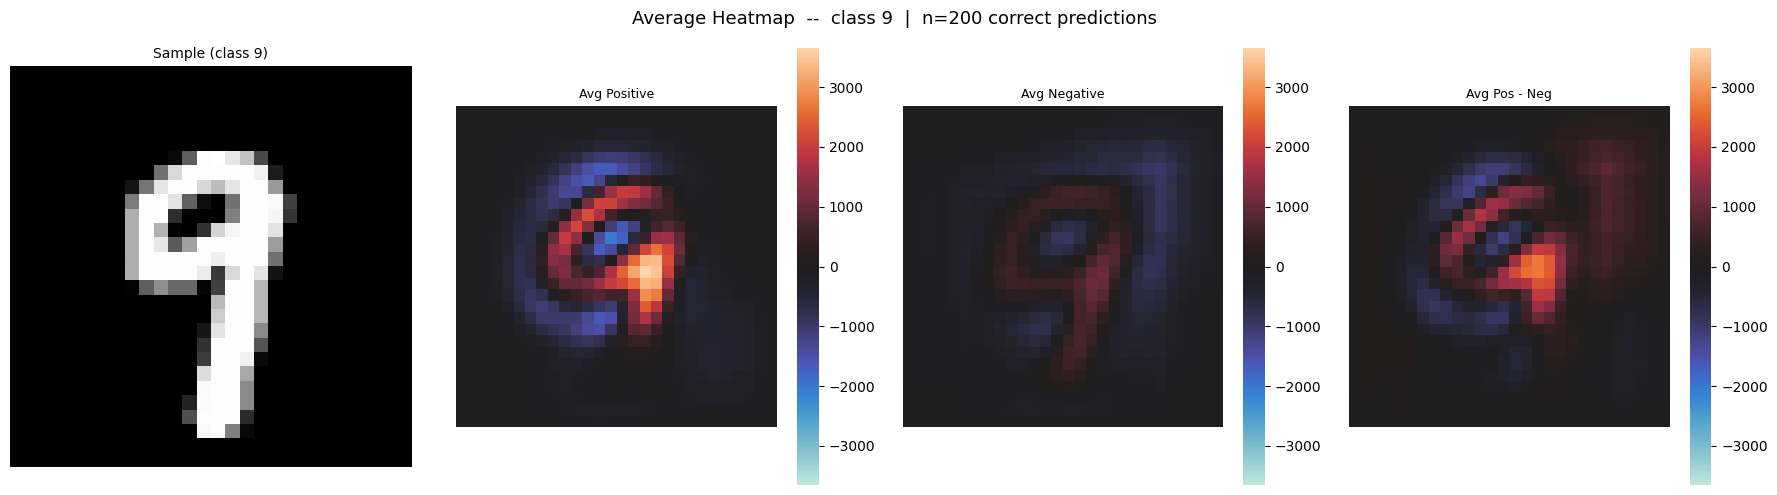

In [11]:
for target_class in range(10):   
    _, _, _ = visualize_average_heatmap(X_test, X_test_org, Y_test, tm,
        resolution=resolution, n_channels=1, image_shape=(28, 28),
        target_class=target_class, max_samples=200)